In [15]:
import pandas as pd
import numpy as np
import statistics 
import seaborn as sns

In [4]:
df = pd.read_csv("raw_sales2.csv")

In [5]:
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


# Function to detect outlier on one dimensional dataset

In [10]:
def find_anomaly(data):
    anomalie = []

    data_std = statistics.stdev(data)
    data_mean = statistics.mean(data)

    three_std = 3 * data_std

    lower_limit = data_mean - three_std
    upper_limit = data_mean + three_std

    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            anomalie.append(outlier)

    return anomalie

In [11]:
outlier = find_anomaly(df["price"])

In [12]:
len(outlier)

461

In [13]:
len(df)

29580

In [14]:
len(outlier)/len(df)*100

1.5584854631507776

# So the data is not normally distributed, as it is not around 0.3 outliers

<Axes: xlabel='price', ylabel='Density'>

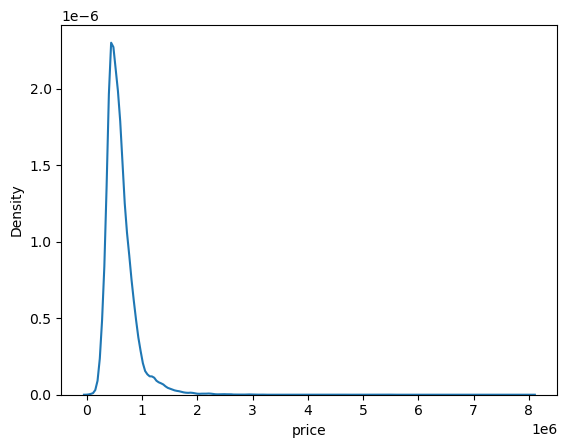

In [16]:
sns.kdeplot(df["price"])

# Right skewed

In [17]:
df["price"] = np.log(df["price"])

In [18]:
df["price"].skew()

np.float64(0.47316462699847633)

In [21]:
len(find_anomaly(df["price"]))

251

In [22]:
df["price"] = np.log(df["price"])

In [23]:
df["price"].skew()

np.float64(0.27591038249718786)

<Axes: xlabel='price', ylabel='Density'>

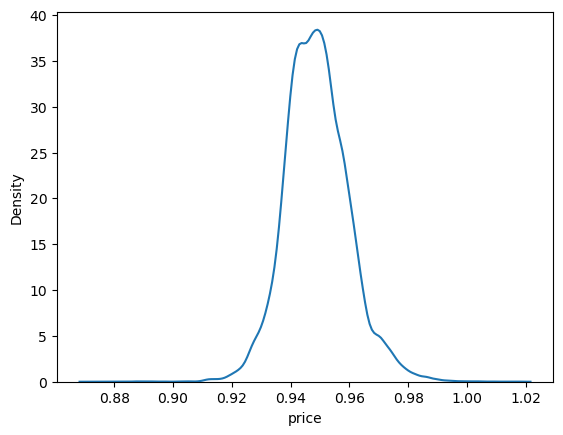

In [24]:
sns.kdeplot(df["price"])

<Axes: >

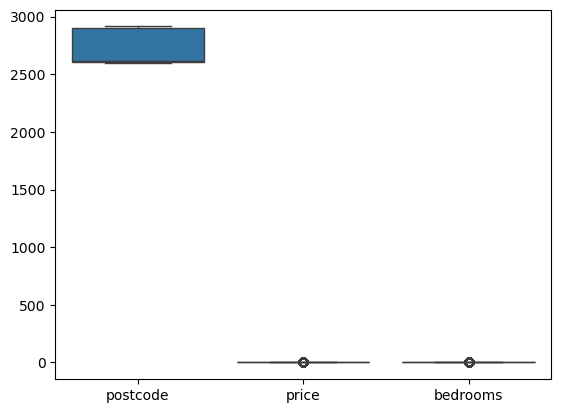

In [25]:
sns.boxplot(df)

# Note: postcode ka scale itna bada hai ke price aur bedrooms almost zero ke paas chipak gaye hain.